# NLP Exploration: Ad Descriptions and Price

**Purpose:** Explore the text descriptions scraped from Hemnet active listings,
understand what language correlates with price, and establish a baseline for
future NLP modelling.

**Date written:** 2026-03-01

---

## ⚠️ Data Situation (read before interpreting results)

### What we have
| Dataset | Rows | Text? | Final price? | Notes |
|---------|------|-------|--------------|-------|
| `description_archive` | 195 | ✓ avg 1,366 chars | ✗ asking price only | Single scrape run 2026-02-08 |
| `active_listings` | 195 | ✓ | ✗ asking price only | Same as archive |
| `properties` (sold) | 22,904 | ✗ | ✓ | Hemnet removes text after sale |
| `description_archive.sold_property_id` | 0 matched | — | — | Tracking only started Feb 2026 |

### The core problem
We want to model: **text → contribution to final sale price**.
But we have:
- Descriptions **only on active listings** (asking price known, final price unknown)
- Final prices **only on sold properties** (no descriptions — Hemnet removes them)
- The `sold_property_id` bridge in `description_archive` is designed to link these,
  but has **0 matches** because the scraping pipeline started too recently.

### What this notebook can do
1. Characterise the description corpus (length, vocabulary, topics)
2. Bigrams/trigrams: what phrases appear most?
3. TF-IDF: which terms are distinctive?
4. Price proxy: correlate text features with **asking price** —
   imperfect (asking ≠ final) but highly correlated (~r=0.95 in Swedish markets)
5. Model residual proxy: predict price from structural features with the price model,
   then see if text explains remaining variance

### 📌 Implementation note for the future
> **Target state:** Once we have ~500 archived descriptions matched to their final
> sale prices via `sold_property_id`, retrain `TextPricePipeline` using
> `final_price - predicted_price` as the target (residuals) rather than the asking-price
> proxy used here. This will produce a much more calibrated word-impact model.
> Check progress with: `SELECT COUNT(*) FROM description_archive WHERE sold_property_id IS NOT NULL`
> The tracking pipeline was set up in Feb 2026 — revisit in **May/June 2026**.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from collections import Counter
import re

# Text / ML
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr, spearmanr

sns.set_style('whitegrid')
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
})
BLUE, ORANGE, GREEN, RED = '#3b82f6', '#f97316', '#10b981', '#ef4444'
DB_PATH = '../data/database/properties.duckdb'

## 1. Data Audit

In [2]:
conn = duckdb.connect(DB_PATH, read_only=True)

# description_archive
arc = conn.execute("""
    SELECT
        COUNT(*)                        AS total,
        COUNT(sold_property_id)         AS matched_to_sold,
        AVG(LENGTH(description))        AS avg_len,
        MIN(LENGTH(description))        AS min_len,
        MAX(LENGTH(description))        AS max_len,
        MIN(first_seen)                 AS earliest,
        MAX(last_seen)                  AS latest,
        COUNT(DISTINCT neighborhood)    AS neighborhoods,
        MEDIAN(asking_price)            AS median_ask,
        COUNT(CASE WHEN asking_price IS NOT NULL THEN 1 END) AS has_price
    FROM description_archive
""").fetchone()

# properties
props = conn.execute("""
    SELECT COUNT(*), COUNT(final_price)
    FROM properties
""").fetchone()

# City breakdown
city_rows = conn.execute("""
    SELECT COALESCE(city, '(null)') as city, COUNT(*) as cnt
    FROM description_archive
    GROUP BY city ORDER BY cnt DESC
    LIMIT 12
""").fetchall()

print("=" * 60)
print("DATA AUDIT")
print("=" * 60)
print(f"\ndescription_archive:")
print(f"  Rows (descriptions):     {arc[0]:>8,}")
print(f"  Matched to sold price:   {arc[1]:>8,}  <- KEY BOTTLENECK")
print(f"  Has asking_price:        {arc[9]:>8,}")
print(f"  Median asking price:     {arc[8]:>8,.0f} kr")
print(f"  Description length:      {arc[4]:>6,.0f} max / {arc[2]:.0f} avg / {arc[3]} min chars")
print(f"  Scrape date range:       {arc[5]} -> {arc[6]}")
print(f"  Distinct neighbourhoods: {arc[7]:>8,}")
print(f"\nCITY DISTRIBUTION (important -- see below):")
malmo_count = 0
for r in city_rows:
    marker = " <-- MALMÖ" if r[0] and 'alm' in r[0].lower() else ""
    print(f"  {str(r[0]):<28} {r[1]:>4}{marker}")
    if r[0] and 'alm' in r[0].lower():
        malmo_count += r[1]

print(f"\n  *** WARNING: only {malmo_count} of {arc[0]} descriptions are from Malmö! ***")
print(f"  The Feb 2026 scrape was not filtered to Malmö -- it captured listings")
print(f"  from across Sweden. NLP correlations below are NATIONAL, not Malmö-specific.")

print(f"\nproperties (sold):")
print(f"  Total:                   {props[0]:>8,}")
print(f"  Has final_price:         {props[1]:>8,}")
print(f"  Has text description:    {'0':>8}  (Hemnet removes text after sale)")
print()
print("CONCLUSION: We have 195 descriptions but 0 linked to final sale price,")
print("and only 4 are from Malmö. Future scrapes should target Malmö exclusively.")
print("Analysis below uses asking_price as a proxy (r~0.9 with final price).")

conn.close()

DATA AUDIT

description_archive:
  Rows (descriptions):          195
  Matched to sold price:          0  <- KEY BOTTLENECK
  Has asking_price:             194
  Median asking price:     1,995,000 kr
  Description length:       3,500 max / 1366 avg / 333 min chars
  Scrape date range:       2026-02-08 -> 2026-02-08
  Distinct neighbourhoods:      146

CITY DISTRIBUTION (important -- see below):
  Stockholm                      19
  (null)                         17
  Helsingborg                    16
  Upplands Väsby                 15
  Vasastan                        7
  Märsta                          6
  Enköping                        6
  Västerås                        5
  Malmö                           4 <-- MALMÖ
  Nordantill                      3
  Hallunda                        3
  Enskede                         3

  *** WARNING: only 4 of 195 descriptions are from Malmö! ***
  The Feb 2026 scrape was not filtered to Malmö -- it captured listings
  from across Sweden. NLP

In [3]:
# Load working dataset
conn = duckdb.connect(DB_PATH, read_only=True)
df = conn.execute("""
    SELECT
        property_id, address, neighborhood, city,
        asking_price, living_area, rooms, building_year,
        association_fee, housing_type, ownership_type,
        latitude, longitude,
        description,
        LENGTH(description) AS desc_len
    FROM description_archive
    WHERE description IS NOT NULL
      AND asking_price IS NOT NULL
      AND living_area IS NOT NULL
      AND living_area > 0
""").df()
conn.close()

df['price_per_sqm'] = df['asking_price'] / df['living_area']
print(f"Working dataset: {len(df)} properties")
print(df[['asking_price', 'living_area', 'rooms', 'price_per_sqm', 'desc_len']].describe().round(0))

Working dataset: 193 properties
       asking_price  living_area  rooms  price_per_sqm  desc_len
count         193.0        193.0  192.0          193.0     193.0
mean      2546575.0         71.0    3.0        38444.0    1356.0
std       1918092.0         29.0    1.0        26473.0     626.0
min        440000.0         18.0    1.0         5963.0     333.0
25%       1375000.0         52.0    2.0        20944.0     916.0
50%       1995000.0         69.0    3.0        29891.0    1279.0
75%       2995000.0         85.0    3.0        45023.0    1771.0
max      13995000.0        166.0    7.0       134775.0    3500.0


## 2. Description Length and Price

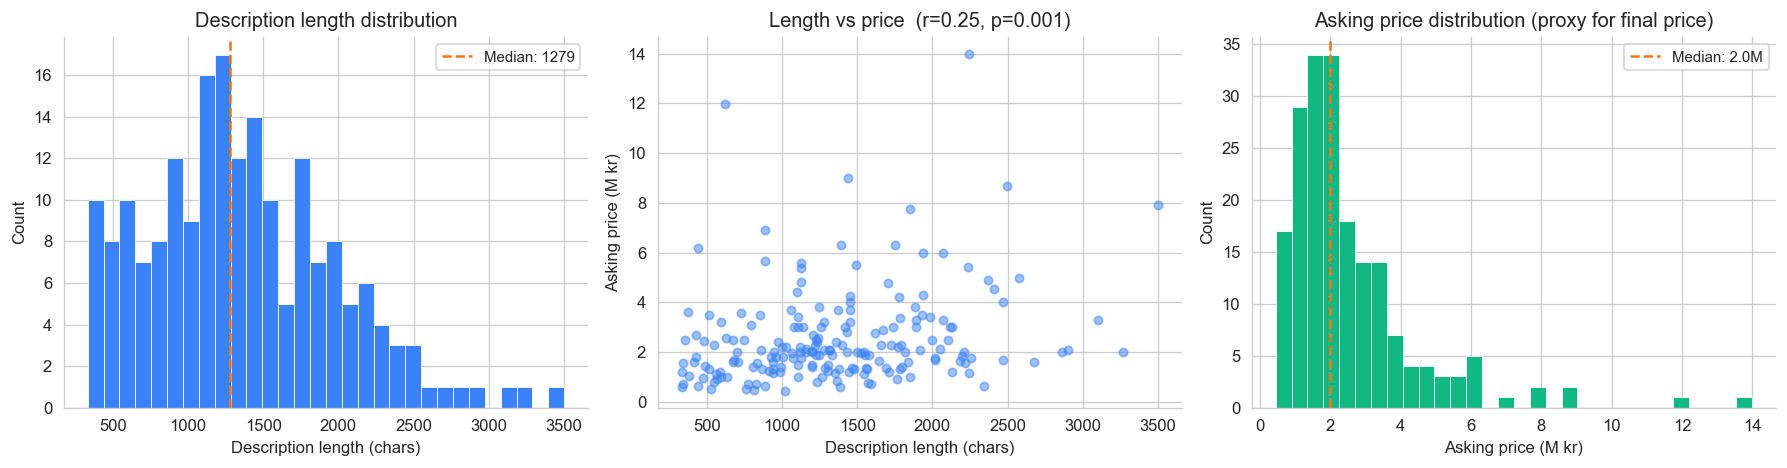

Length-price Pearson r = 0.247  (p=0.001)


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Description length distribution
axes[0].hist(df['desc_len'], bins=30, color=BLUE, edgecolor='white', linewidth=0.5)
axes[0].set_xlabel('Description length (chars)')
axes[0].set_ylabel('Count')
axes[0].set_title('Description length distribution')
axes[0].axvline(df['desc_len'].median(), color=ORANGE, linestyle='--', label=f'Median: {df["desc_len"].median():.0f}')
axes[0].legend(fontsize=9)

# Length vs asking price
axes[1].scatter(df['desc_len'], df['asking_price'] / 1e6,
                alpha=0.5, s=25, color=BLUE)
r, p = pearsonr(df['desc_len'], df['asking_price'])
axes[1].set_xlabel('Description length (chars)')
axes[1].set_ylabel('Asking price (M kr)')
axes[1].set_title(f'Length vs price  (r={r:.2f}, p={p:.3f})')

# Asking price distribution
axes[2].hist(df['asking_price'] / 1e6, bins=30, color=GREEN, edgecolor='white', linewidth=0.5)
axes[2].set_xlabel('Asking price (M kr)')
axes[2].set_ylabel('Count')
axes[2].set_title('Asking price distribution (proxy for final price)')
axes[2].axvline(df['asking_price'].median() / 1e6, color=ORANGE, linestyle='--',
                label=f'Median: {df["asking_price"].median()/1e6:.1f}M')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig('nlp_desc_length.png', bbox_inches='tight', dpi=120)
plt.show()
print(f"Length-price Pearson r = {r:.3f}  (p={p:.3f})")

## 3. Text Preprocessing

In [5]:
# Swedish stop words + domain-specific boilerplate
STOP_WORDS = {
    # Common Swedish
    'och', 'av', 'att', 'en', 'ett', 'är', 'i', 'på', 'med', 'det', 'den',
    'för', 'som', 'till', 'om', 'har', 'de', 'vi', 'du', 'han', 'hon',
    'se', 'ni', 'kan', 'vara', 'var', 'finns', 'mot', 'vid', 'ur', 'via',
    'sin', 'sina', 'sitt', 'sig', 'man', 'men', 'inte', 'från', 'efter',
    'under', 'över', 'upp', 'ut', 'in', 'andra', 'alla', 'eller', 'om',
    'samt', 'även', 'här', 'nu', 'just', 'bl', 'också', 'mycket', 'ger',
    'den', 'detta', 'dessa', 'detta', 'ett', 'vad', 'tar', 'ger',
    # Housing boilerplate — these appear in almost every listing
    'bostadsrätt', 'lägenhet', 'lägenheten', 'rum', 'kök', 'kv', 'kvm',
    'avgift', 'kr', 'månaden', 'boyta', 'boarea', 'kr/mån', 'mån',
    'hemnet', 'fastighetsbyrå', 'mäklare', 'välkommen', 'välkomna',
    'kontakta', 'visning', 'boka', 'budgivning', 'bud',
    # Numbers / sizes often end up as tokens
    'ca', 'ca.', 'st', 'sq',
}

def preprocess(text: str) -> str:
    """Clean a Swedish property description for NLP."""
    if not text:
        return ''
    # Lowercase
    text = text.lower()
    # Remove HTML tags
    text = re.sub(r'<[^>]+>', ' ', text)
    # Remove URLs
    text = re.sub(r'https?://\S+', ' ', text)
    # Remove prices / areas: 1 500 000 kr, 65 kvm, 3 500 kr/mån
    text = re.sub(r'\d[\d\s]*(?:kr|kvm|m²|mån|rum|rok|tr)', ' ', text)
    # Remove remaining standalone numbers
    text = re.sub(r'\b\d+\b', ' ', text)
    # Remove punctuation except Swedish letters
    text = re.sub(r'[^a-zåäö\s]', ' ', text)
    # Collapse whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['text_clean'] = df['description'].apply(preprocess)

# Tokenise and remove stop words
def tokenize(text: str) -> list[str]:
    return [w for w in text.split() if len(w) >= 3 and w not in STOP_WORDS]

df['tokens'] = df['text_clean'].apply(tokenize)

# Vocabulary stats
all_tokens = [t for tokens in df['tokens'] for t in tokens]
vocab = Counter(all_tokens)
print(f"Total tokens (post-cleaning): {len(all_tokens):,}")
print(f"Unique tokens:                {len(vocab):,}")
print(f"\nTop 30 tokens:")
for word, count in vocab.most_common(30):
    print(f"  {word:<20} {count:>4}")

Total tokens (post-cleaning): 22,971
Unique tokens:                4,245

Top 30 tokens:
  både                  232
  plats                 214
  dig                   176
  erbjuder              164
  bostaden              163
  denna                 161
  två                   144
  där                   140
  perfekt               140
  sovrum                137
  bor                   129
  gott                  127
  förvaring             127
  stora                 124
  närhet                121
  läge                  119
  planlösning           116
  hem                   113
  köket                 106
  ligger                105
  vardagsrummet          96
  balkong                96
  badrum                 96
  vardagsrum             94
  bra                    93
  vilket                 88
  extra                  88
  centrum                87
  badrummet              83
  varmt                  79


## 4. Unigram Analysis

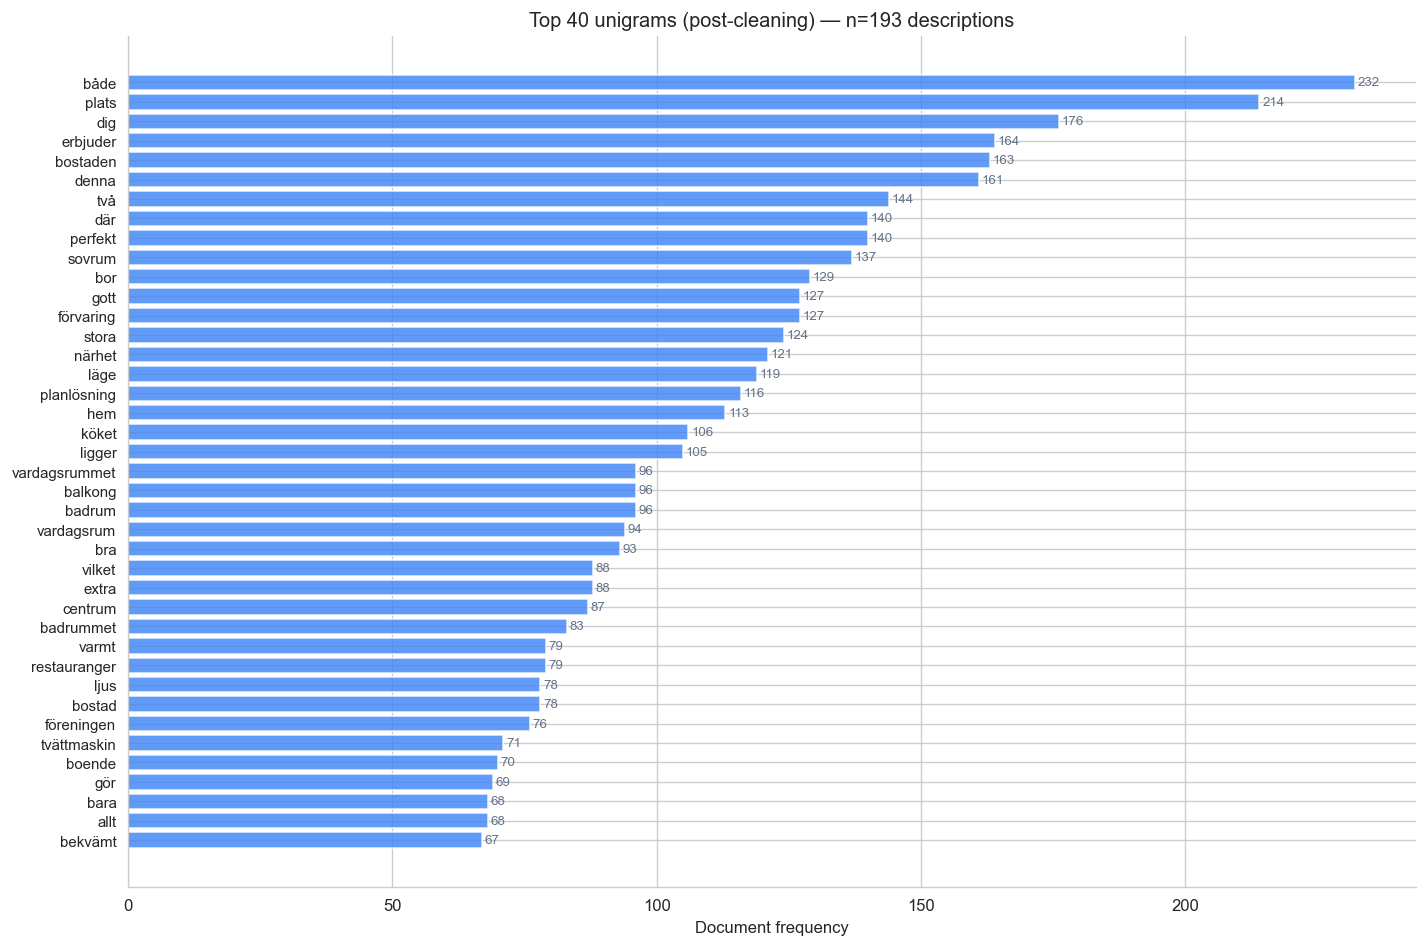

In [6]:
top_n = 40
top_words = vocab.most_common(top_n)
words, counts = zip(*top_words)

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(range(len(words)), counts, color=BLUE, alpha=0.8)
ax.set_yticks(range(len(words)))
ax.set_yticklabels(words, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Document frequency')
ax.set_title(f'Top {top_n} unigrams (post-cleaning) — n={len(df)} descriptions')
# Add value labels
for i, (bar, cnt) in enumerate(zip(bars, counts)):
    ax.text(cnt + 0.5, i, str(cnt), va='center', fontsize=8, color='#64748b')
plt.tight_layout()
plt.savefig('nlp_unigrams.png', bbox_inches='tight', dpi=120)
plt.show()

## 5. Bigrams and Trigrams

Total distinct bigrams:  16,706
Total distinct trigrams: 20,987


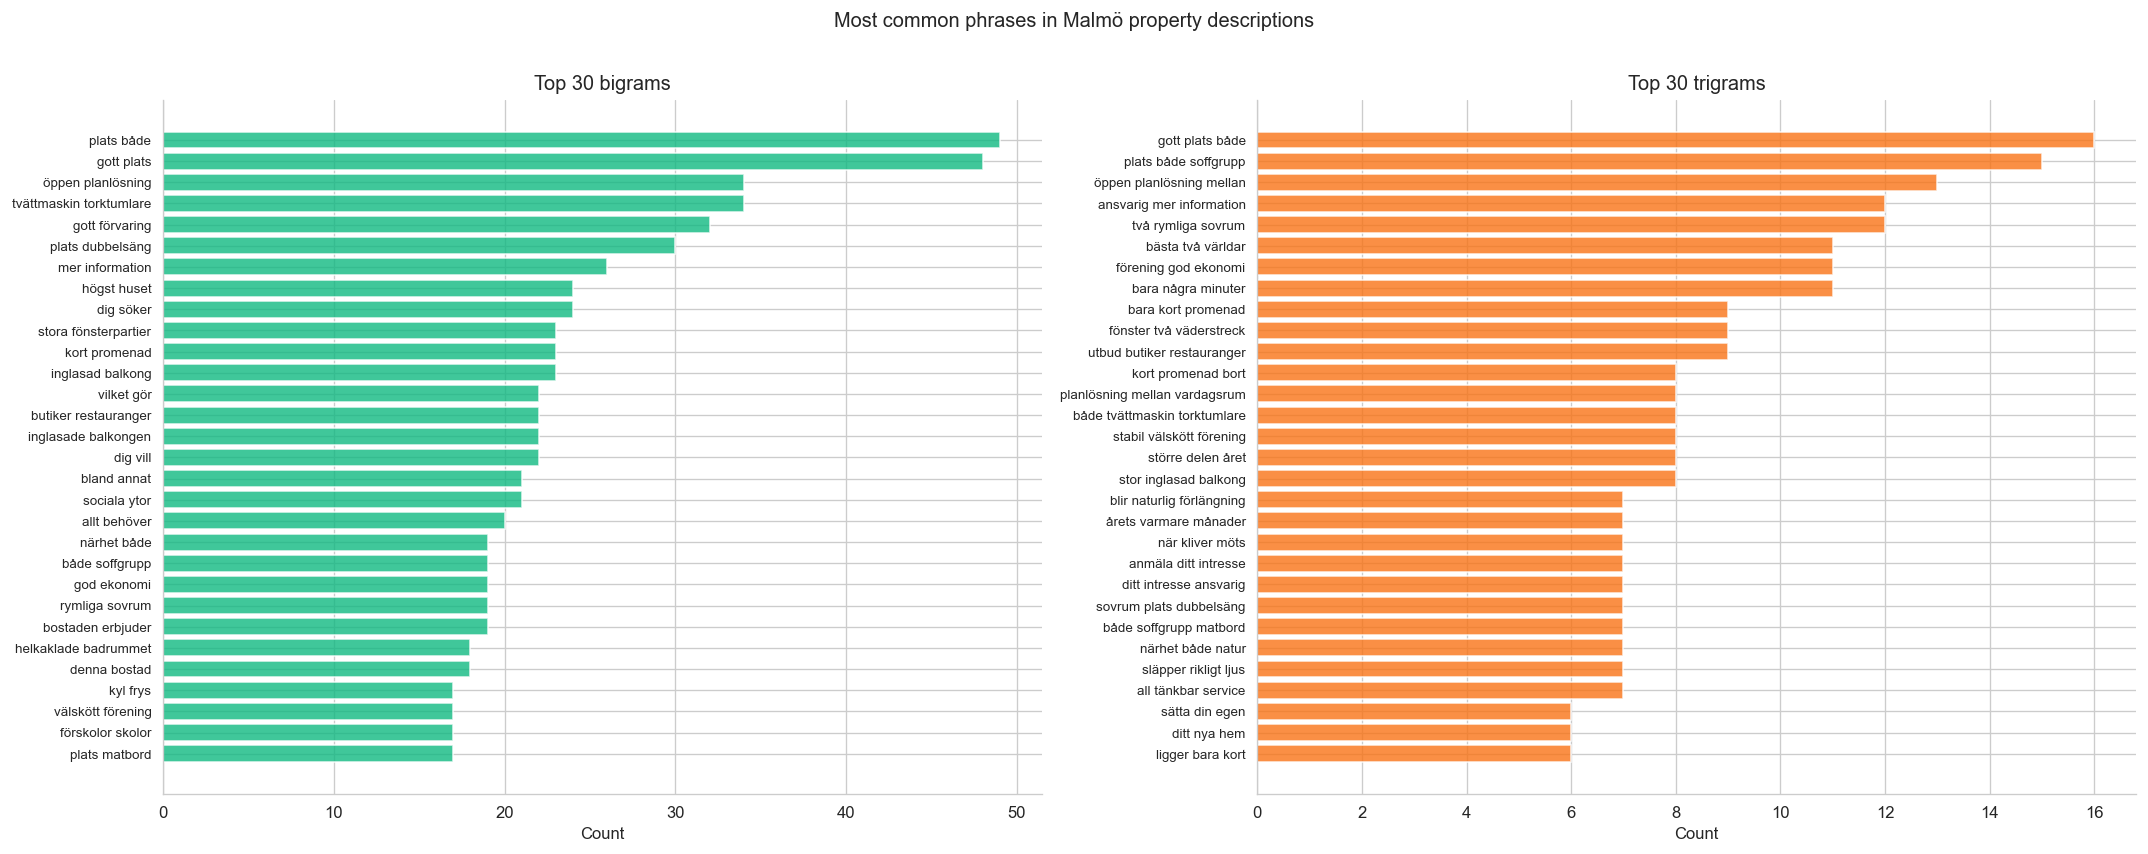

In [7]:
def extract_ngrams(tokens_list, n):
    """Count n-grams across all documents."""
    ngram_counter = Counter()
    for tokens in tokens_list:
        for i in range(len(tokens) - n + 1):
            ngram = ' '.join(tokens[i:i+n])
            ngram_counter[ngram] += 1
    return ngram_counter

bigrams = extract_ngrams(df['tokens'], 2)
trigrams = extract_ngrams(df['tokens'], 3)

print(f"Total distinct bigrams:  {len(bigrams):,}")
print(f"Total distinct trigrams: {len(trigrams):,}")

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Bigrams
n_show = 30
top_bi = bigrams.most_common(n_show)
bi_words, bi_counts = zip(*top_bi)
axes[0].barh(range(len(bi_words)), bi_counts, color=GREEN, alpha=0.8)
axes[0].set_yticks(range(len(bi_words)))
axes[0].set_yticklabels(bi_words, fontsize=8)
axes[0].invert_yaxis()
axes[0].set_xlabel('Count')
axes[0].set_title(f'Top {n_show} bigrams')

# Trigrams
top_tri = trigrams.most_common(n_show)
tri_words, tri_counts = zip(*top_tri)
axes[1].barh(range(len(tri_words)), tri_counts, color=ORANGE, alpha=0.8)
axes[1].set_yticks(range(len(tri_words)))
axes[1].set_yticklabels(tri_words, fontsize=8)
axes[1].invert_yaxis()
axes[1].set_xlabel('Count')
axes[1].set_title(f'Top {n_show} trigrams')

plt.suptitle('Most common phrases in Malmö property descriptions', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('nlp_ngrams.png', bbox_inches='tight', dpi=120)
plt.show()

In [8]:
# Interpretation: annotate top bigrams/trigrams
print("TOP 20 BIGRAMS (interpretation)")
for phrase, count in bigrams.most_common(20):
    print(f"  {phrase:<35}  {count:>3}")
print()
print("TOP 20 TRIGRAMS")
for phrase, count in trigrams.most_common(20):
    print(f"  {phrase:<40}  {count:>3}")

TOP 20 BIGRAMS (interpretation)
  plats både                            49
  gott plats                            48
  öppen planlösning                     34
  tvättmaskin torktumlare               34
  gott förvaring                        32
  plats dubbelsäng                      30
  mer information                       26
  högst huset                           24
  dig söker                             24
  stora fönsterpartier                  23
  kort promenad                         23
  inglasad balkong                      23
  vilket gör                            22
  butiker restauranger                  22
  inglasade balkongen                   22
  dig vill                              22
  bland annat                           21
  sociala ytor                          21
  allt behöver                          20
  närhet både                           19

TOP 20 TRIGRAMS
  gott plats både                            16
  plats både soffgrupp                     

## 6. TF-IDF Analysis

TF-IDF matrix: 193 docs × 1000 features
Sparsity: 90.9%


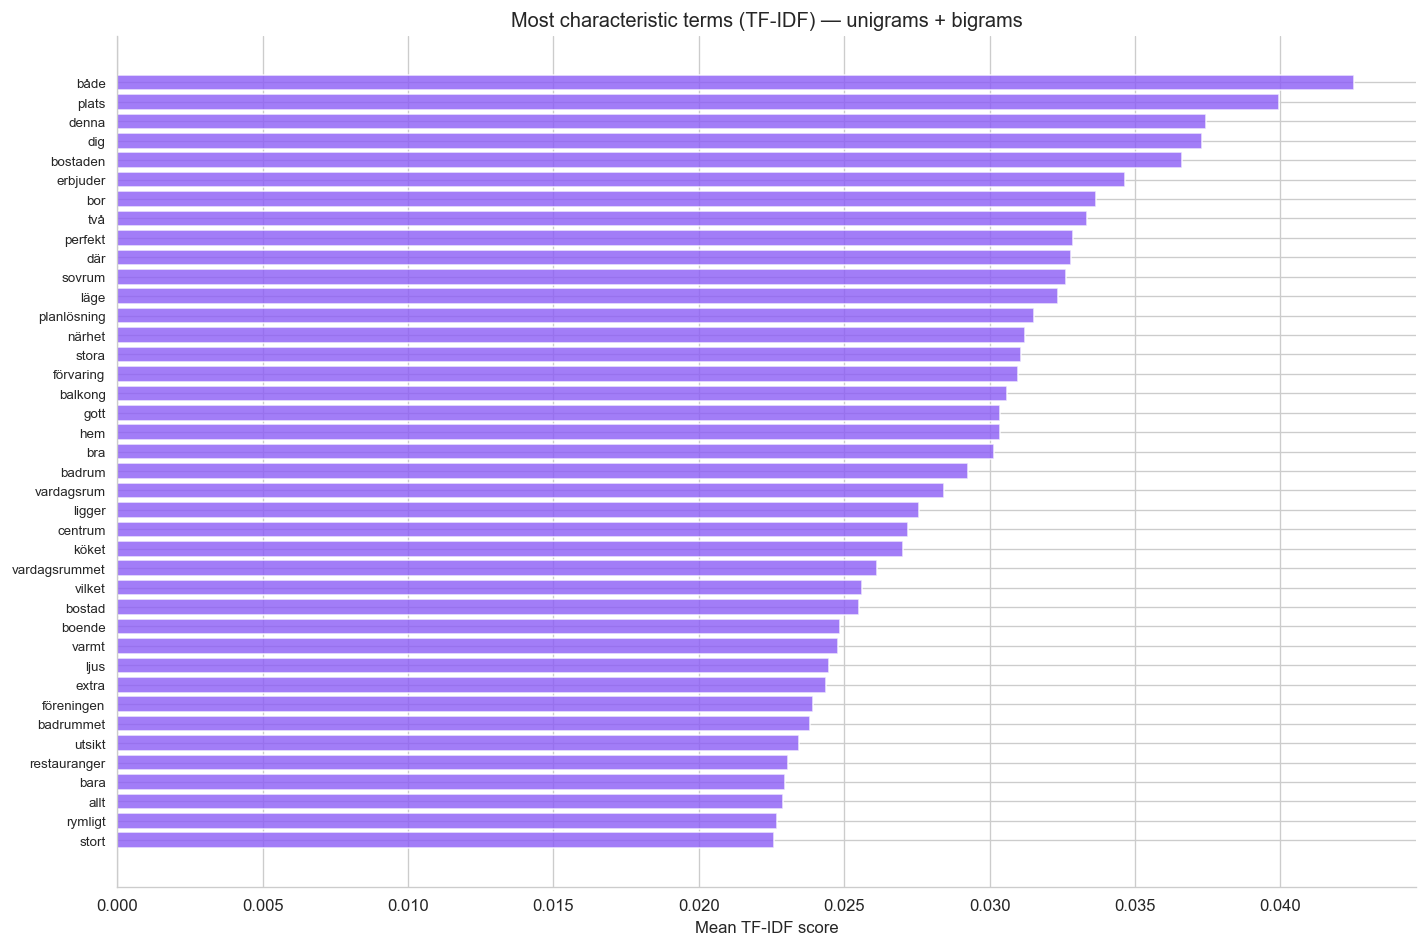

In [9]:
# TF-IDF with Swedish-specific settings
tfidf = TfidfVectorizer(
    preprocessor=preprocess,
    token_pattern=r'(?u)\b[a-zåäö]{3,}\b',
    stop_words=list(STOP_WORDS),
    ngram_range=(1, 2),
    max_features=1000,
    min_df=3,
    max_df=0.90,
    sublinear_tf=True,
)

X = tfidf.fit_transform(df['description'])
feature_names = tfidf.get_feature_names_out()

print(f"TF-IDF matrix: {X.shape[0]} docs × {X.shape[1]} features")
print(f"Sparsity: {1 - X.nnz / (X.shape[0] * X.shape[1]):.1%}")

# Mean TF-IDF per feature (proxy for 'how characteristic is this term')
mean_tfidf = np.array(X.mean(axis=0)).flatten()
top_idx = mean_tfidf.argsort()[::-1][:40]

fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(range(40), mean_tfidf[top_idx], color='#8b5cf6', alpha=0.8)
ax.set_yticks(range(40))
ax.set_yticklabels([feature_names[i] for i in top_idx], fontsize=8)
ax.invert_yaxis()
ax.set_xlabel('Mean TF-IDF score')
ax.set_title('Most characteristic terms (TF-IDF) — unigrams + bigrams')
plt.tight_layout()
plt.savefig('nlp_tfidf.png', bbox_inches='tight', dpi=120)
plt.show()

## 7. TF-IDF Terms vs Price (Proxy Analysis)

This section uses **asking price** as a proxy for final price. Since we only have
195 observations, treat correlations here as directional signals only — not robust estimates.

In [10]:
# Correlation of each TF-IDF feature with asking_price / sqm
y_ask = df['asking_price'].values
y_psm = df['price_per_sqm'].values

X_dense = X.toarray()
correlations = []
for i, feat in enumerate(feature_names):
    col = X_dense[:, i]
    if col.sum() == 0:
        continue
    r_ask, p_ask = spearmanr(col, y_ask)
    r_psm, p_psm = spearmanr(col, y_psm)
    doc_freq = (col > 0).sum()
    correlations.append({
        'term': feat,
        'r_ask': r_ask,
        'r_psm': r_psm,
        'p_psm': p_psm,
        'doc_freq': doc_freq,
    })

corr_df = pd.DataFrame(correlations).sort_values('r_psm', ascending=False)

# Filter to terms appearing in >= 5 documents for reliability
corr_df_filtered = corr_df[corr_df['doc_freq'] >= 5].reset_index(drop=True)
print(f"Terms appearing in ≥5 docs: {len(corr_df_filtered)}")
print(f"\n--- Top 20 POSITIVE correlation with price/m² ---")
print(corr_df_filtered.head(20)[['term', 'r_psm', 'p_psm', 'doc_freq']].to_string(index=False))
print(f"\n--- Top 20 NEGATIVE correlation with price/m² ---")
print(corr_df_filtered.tail(20)[['term', 'r_psm', 'p_psm', 'doc_freq']].iloc[::-1].to_string(index=False))

Terms appearing in ≥5 docs: 991

--- Top 20 POSITIVE correlation with price/m² ---
             term    r_psm        p_psm  doc_freq
              caf 0.346899 7.720563e-07        29
           marken 0.298627 2.460720e-05        12
         odenplan 0.292610 3.636907e-05         6
       vasaparken 0.288624 4.688870e-05         6
      tunnelbanan 0.288055 4.860553e-05         9
   fönsterpartier 0.278728 8.668390e-05        25
             äger 0.270625 1.409484e-04        11
      materialval 0.268337 1.612486e-04        34
        eriksplan 0.264067 2.066087e-04         5
             mest 0.261696 2.366820e-04        14
         stenkast 0.260814 2.488759e-04        18
     restauranger 0.258895 2.774350e-04        75
             form 0.257376 3.021881e-04        10
             city 0.253848 3.677766e-04        24
öppen planlösning 0.253691 3.709871e-04        33
       tunnelbana 0.252970 3.860262e-04        13
      äger marken 0.249579 4.647390e-04        10
         populära

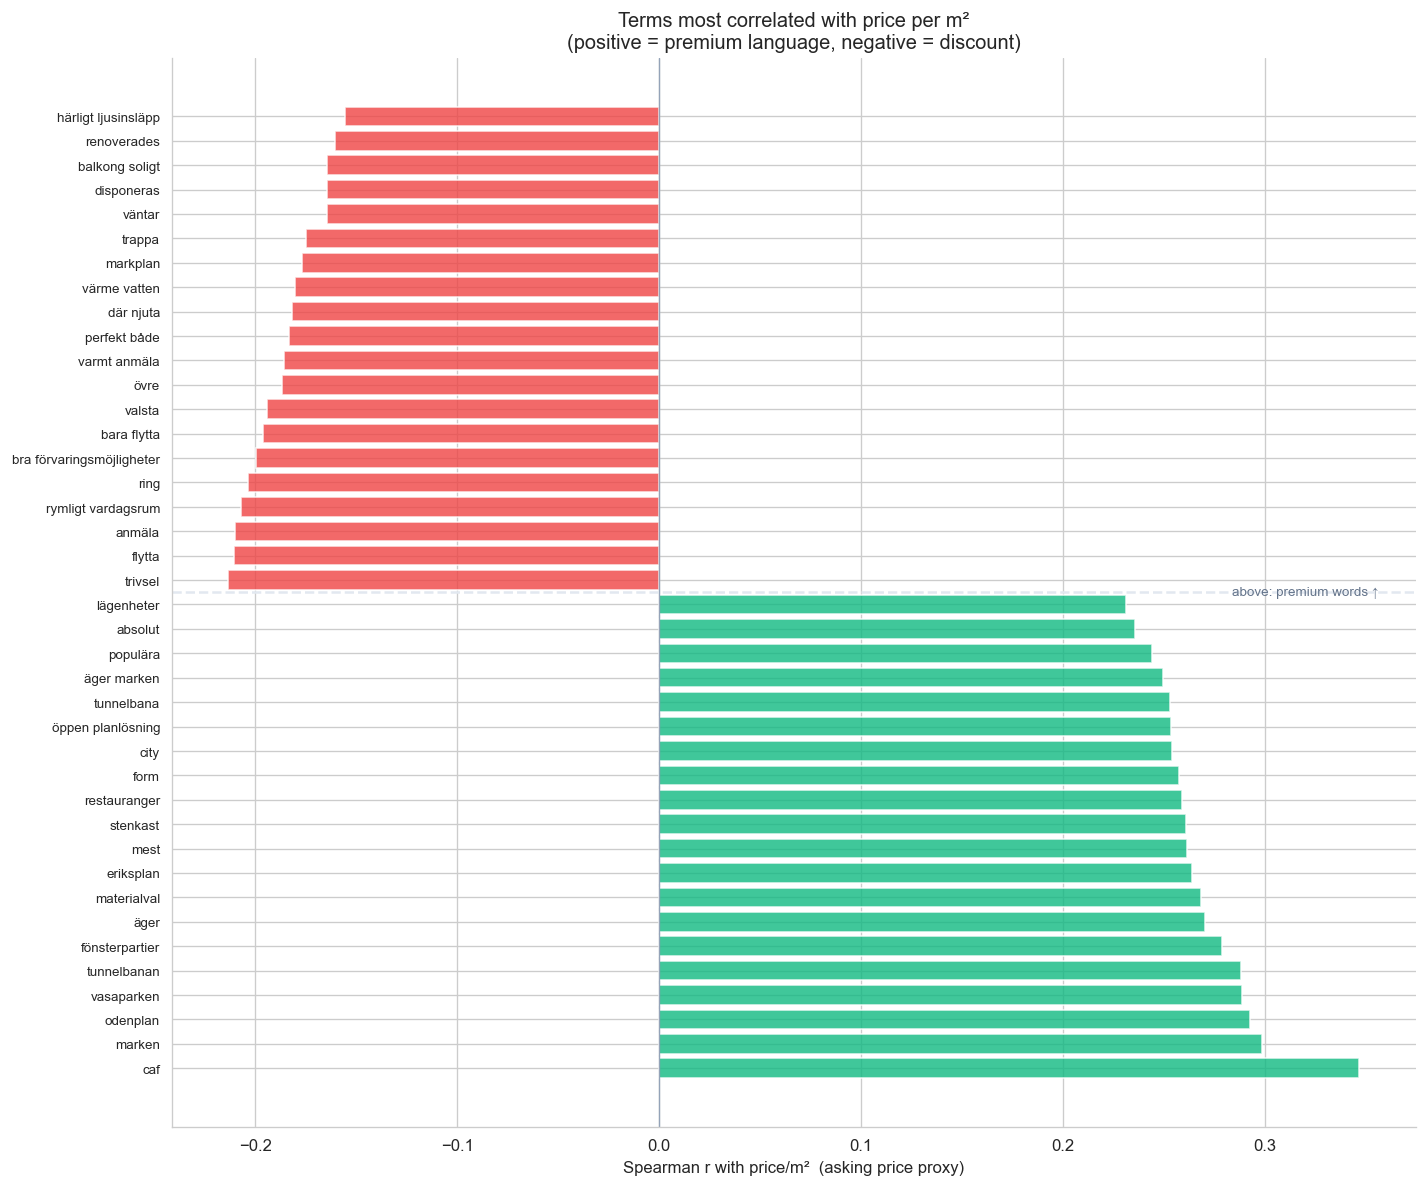

In [11]:
# Plot: top positive and negative correlators
n_show = 20
top_pos = corr_df_filtered.head(n_show)
top_neg = corr_df_filtered.tail(n_show).iloc[::-1]
combined = pd.concat([top_pos, top_neg])

fig, ax = plt.subplots(figsize=(12, 10))
colors = [GREEN if r > 0 else RED for r in combined['r_psm']]
bars = ax.barh(range(len(combined)), combined['r_psm'], color=colors, alpha=0.8)
ax.set_yticks(range(len(combined)))
ax.set_yticklabels(combined['term'], fontsize=8)
ax.axvline(0, color='#94a3b8', linewidth=0.8)
ax.set_xlabel('Spearman r with price/m²  (asking price proxy)')
ax.set_title('Terms most correlated with price per m²\n(positive = premium language, negative = discount)')

# Separate horizontal line between positive and negative
ax.axhline(n_show - 0.5, color='#e2e8f0', linewidth=1.5, linestyle='--')
ax.text(ax.get_xlim()[1] * 0.95, n_show - 0.5, 'above: premium words ↑', 
        va='center', ha='right', fontsize=8, color='#64748b')

plt.tight_layout()
plt.savefig('nlp_term_correlations.png', bbox_inches='tight', dpi=120)
plt.show()

## 8. Ridge Regression: Text → Price Residual

Use the structural price model to predict asking price from features,
then test whether TF-IDF can explain the residuals.

In [12]:
# Predict price from structural features using the price model
import sys
sys.path.insert(0, '..')

try:
    from pathlib import Path
    from src.models.prediction_service import PredictionService
    import datetime

    svc = PredictionService.from_artifact(Path('../models/price_model.joblib'))

    preds = []
    for _, row in df.iterrows():
        try:
            result = svc.predict(
                rooms=float(row['rooms']) if pd.notna(row['rooms']) else 2.0,
                living_area=float(row['living_area']),
                association_fee=float(row['association_fee']) if pd.notna(row['association_fee']) else 3000.0,
                building_year=int(row['building_year']) if pd.notna(row['building_year']) else 1970,
                latitude=float(row['latitude']) if pd.notna(row['latitude']) else 55.605,
                longitude=float(row['longitude']) if pd.notna(row['longitude']) else 13.003,
                neighborhood=str(row['neighborhood']) if pd.notna(row['neighborhood']) else '',
                housing_type=str(row['housing_type']) if pd.notna(row['housing_type']) else 'Lägenhet',
                ownership_type=str(row['ownership_type']) if pd.notna(row['ownership_type']) else 'Bostadsrätt',
                target_date=datetime.date.today(),
            )
            preds.append(result.predicted_price)
        except Exception:
            preds.append(None)

    df['predicted_price'] = preds
    df_model = df[df['predicted_price'].notna()].copy()
    df_model['residual'] = df_model['asking_price'] - df_model['predicted_price']
    df_model['residual_pct'] = df_model['residual'] / df_model['predicted_price'] * 100

    print(f"Properties with predictions: {len(df_model)}")
    print(f"\nResidual stats (asking - predicted):")
    print(f"  Mean:   {df_model['residual'].mean():>10,.0f} kr ({df_model['residual_pct'].mean():.1f}%)")
    print(f"  Median: {df_model['residual'].median():>10,.0f} kr ({df_model['residual_pct'].median():.1f}%)")
    print(f"  Std:    {df_model['residual'].std():>10,.0f} kr")
    model_loaded = True

except Exception as e:
    print(f"Could not load price model: {e}")
    print("Falling back to asking_price as target")
    df['predicted_price'] = None
    df['residual'] = df['asking_price']
    df['residual_pct'] = 0.0
    df_model = df.copy()
    model_loaded = False

Properties with predictions: 193

Residual stats (asking - predicted):
  Mean:     -130,472 kr (11.3%)
  Median:   -154,000 kr (-7.3%)
  Std:     2,052,546 kr


In [13]:
# Refit TF-IDF on the model subset
X_model = tfidf.transform(df_model['description'])
y_resid = df_model['residual'].values

# Cross-validated Ridge regression: text → residual
scaler = StandardScaler(with_mean=False)
X_scaled = scaler.fit_transform(X_model)

alphas = [0.01, 0.1, 1.0, 10.0, 100.0]
scores = []
for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    cv_scores = cross_val_score(ridge, X_scaled, y_resid, cv=5, scoring='r2')
    scores.append({'alpha': alpha, 'mean_r2': cv_scores.mean(), 'std_r2': cv_scores.std()})

scores_df = pd.DataFrame(scores)
print("5-fold CV R² for Ridge (text → price residual):")
print(scores_df.to_string(index=False))
print()
best_alpha = scores_df.loc[scores_df['mean_r2'].idxmax(), 'alpha']
best_r2 = scores_df['mean_r2'].max()
print(f"Best alpha: {best_alpha}  R²={best_r2:.3f}")
print()
if best_r2 < 0.05:
    print("⚠️  R² near zero — text explains almost no variance in price residual.")
    print("   This is EXPECTED with only 195 examples — need more data before drawing conclusions.")
elif best_r2 < 0.20:
    print(f"✓ Modest signal: text explains {best_r2:.1%} of residual variance.")
else:
    print(f"✓ Meaningful signal: text explains {best_r2:.1%} of residual variance.")

5-fold CV R² for Ridge (text → price residual):
 alpha  mean_r2   std_r2
  0.01 0.239611 0.047640
  0.10 0.239636 0.047632
  1.00 0.239887 0.047545
 10.00 0.242221 0.046790
100.00 0.256813 0.044795

Best alpha: 100.0  R²=0.257

✓ Meaningful signal: text explains 25.7% of residual variance.


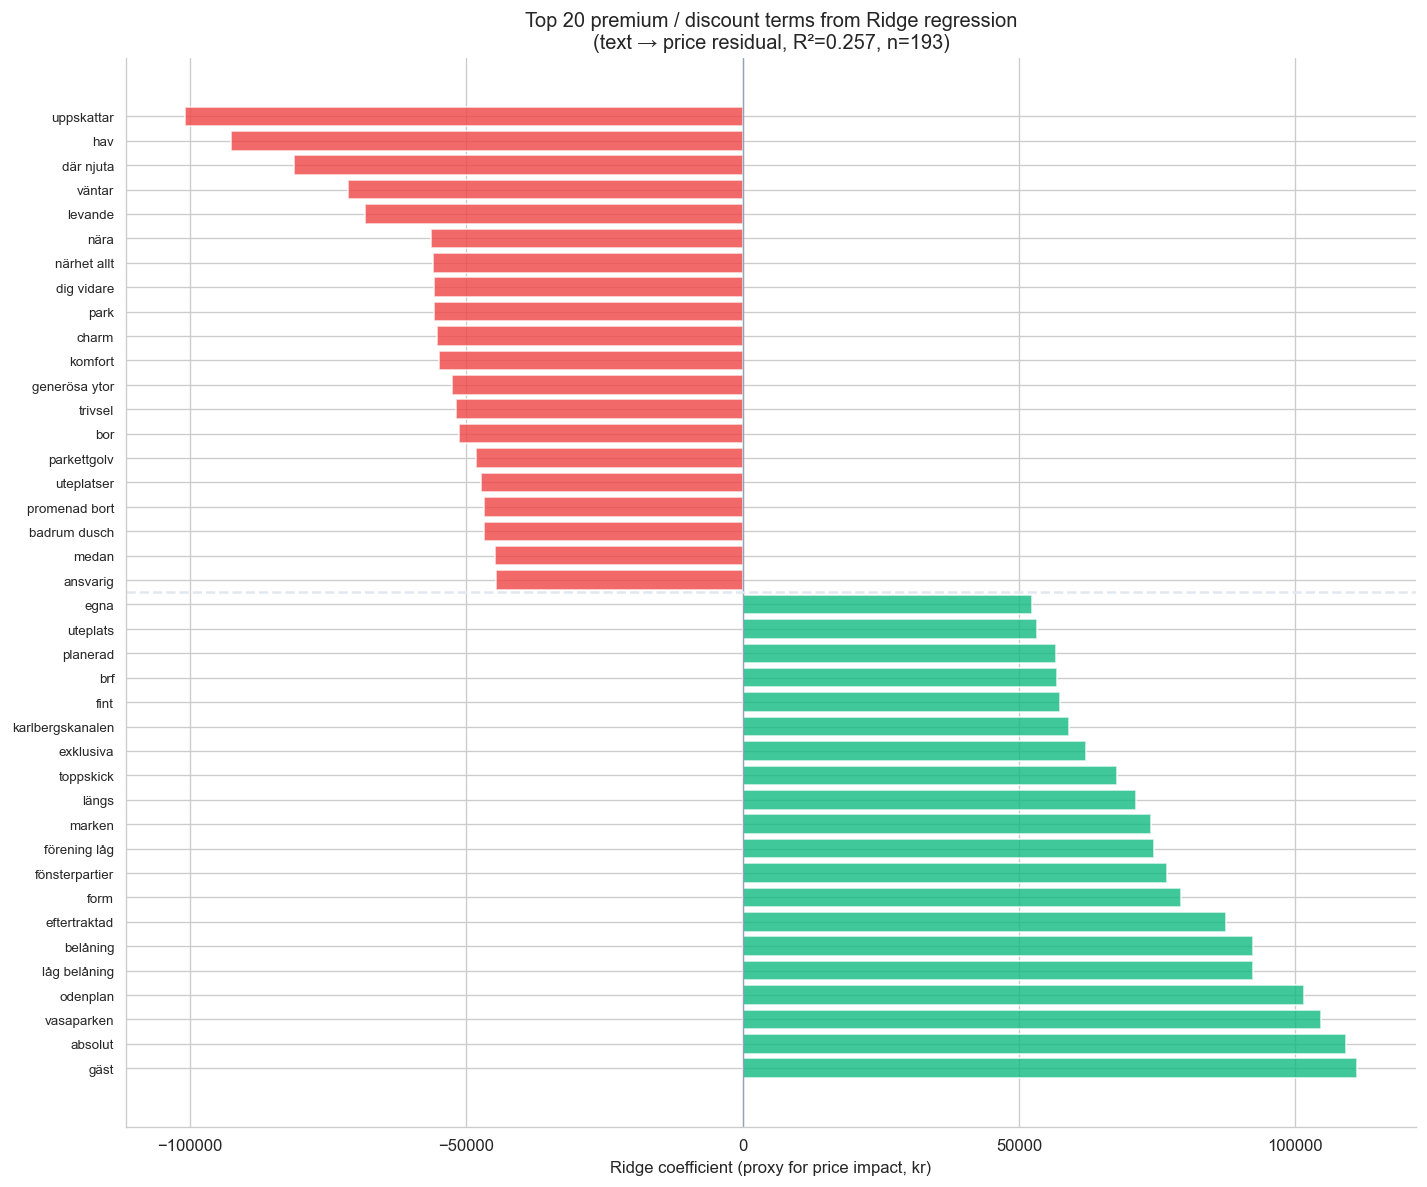

TOP 20 PREMIUM TERMS (positive Ridge coef):
            term   coefficient
            gäst 111212.522392
         absolut 109130.588735
      vasaparken 104548.761563
        odenplan 101626.554722
    låg belåning  92310.201237
        belåning  92310.201237
    eftertraktad  87380.795384
            form  79243.558985
  fönsterpartier  76689.040298
    förening låg  74448.659477
          marken  73917.870932
           längs  71205.253676
       toppskick  67650.769043
       exklusiva  62147.544167
karlbergskanalen  59112.208841
            fint  57393.499224
             brf  56796.724764
        planerad  56768.901856
        uteplats  53199.353074
            egna  52377.586550

TOP 20 DISCOUNT TERMS (negative Ridge coef):
         term    coefficient
   uppskattar -100990.505325
          hav  -92567.371738
    där njuta  -81143.958204
       väntar  -71496.036754
      levande  -68350.193745
         nära  -56359.077420
  närhet allt  -56011.705749
   dig vidare  -55941.02966

In [14]:
# Fit final Ridge and extract word coefficients
final_ridge = Ridge(alpha=best_alpha)
final_ridge.fit(X_scaled, y_resid)

coef_df = pd.DataFrame({
    'term': feature_names,
    'coefficient': final_ridge.coef_,
}).sort_values('coefficient', ascending=False)

n_show = 20
top_coef = pd.concat([coef_df.head(n_show), coef_df.tail(n_show)])

fig, ax = plt.subplots(figsize=(12, 10))
colors = [GREEN if c > 0 else RED for c in top_coef['coefficient']]
ax.barh(range(len(top_coef)), top_coef['coefficient'], color=colors, alpha=0.8)
ax.set_yticks(range(len(top_coef)))
ax.set_yticklabels(top_coef['term'], fontsize=8)
ax.axvline(0, color='#94a3b8', linewidth=0.8)
ax.axhline(n_show - 0.5, color='#e2e8f0', linewidth=1.5, linestyle='--')
ax.set_xlabel('Ridge coefficient (proxy for price impact, kr)')
ax.set_title(
    f'Top {n_show} premium / discount terms from Ridge regression\n'
    f'(text → price residual, R²={best_r2:.3f}, n={len(df_model)})'
)
plt.tight_layout()
plt.savefig('nlp_ridge_coefs.png', bbox_inches='tight', dpi=120)
plt.show()

print("TOP 20 PREMIUM TERMS (positive Ridge coef):")
print(coef_df.head(20)[['term', 'coefficient']].to_string(index=False))
print("\nTOP 20 DISCOUNT TERMS (negative Ridge coef):")
print(coef_df.tail(20)[['term', 'coefficient']].iloc[::-1].to_string(index=False))

## 9. Thematic Clusters

Group terms into semantic categories to identify recurring themes.

In [15]:
# Define thematic word lists based on what we see in Swedish listings
THEMES = {
    'Luxury / Prestige': [
        'exklusiv', 'lyxig', 'premium', 'välutrustat', 'representativ',
        'påkostat', 'hög standard', 'hög klass', 'generöst', 'rymlig', 'lyxig'
    ],
    'Light / Space': [
        'ljus', 'ljust', 'ljusa', 'ljusinsläpp', 'rymlig', 'rymd', 'öppen',
        'luftig', 'genomgående', 'öppet', 'panorama'
    ],
    'Renovation / New': [
        'renoverad', 'nyrenoverad', 'nybyggd', 'nyproducerad', 'ny', 'nya',
        'modern', 'modernt', 'tidsenlig', 'uppdaterad', 'fräsch', 'fräscht'
    ],
    'Outdoor / View': [
        'balkong', 'terrass', 'uteplats', 'utsikt', 'havsutsikt', 'trädgård',
        'innergård', 'pool', 'sjöutsikt'
    ],
    'Location': [
        'centralt', 'central', 'promenadavstånd', 'gångavstånd', 'kollektivtrafik',
        'kommunikationer', 'pendel', 'hav', 'strand', 'hamnen'
    ],
    'Condition / Older': [
        'renoveringsobjekt', 'renoveringsbehov', 'äldre', 'charmig', 'original',
        'orört', 'karaktär', 'originaldetaljer'
    ],
}

# For each theme, count how many descriptions contain ≥1 theme word
# and compute median price/sqm for those properties
theme_results = []
for theme, keywords in THEMES.items():
    pattern = '|'.join(keywords)
    mask = df_model['text_clean'].str.contains(pattern, case=False, na=False)
    n_match = mask.sum()
    if n_match < 3:
        continue
    median_psm_theme = df_model.loc[mask, 'price_per_sqm'].median()
    median_psm_rest = df_model.loc[~mask, 'price_per_sqm'].median()
    theme_results.append({
        'theme': theme,
        'n_with': n_match,
        'n_without': (~mask).sum(),
        'median_psm_with': median_psm_theme,
        'median_psm_without': median_psm_rest,
        'diff_pct': (median_psm_theme / median_psm_rest - 1) * 100,
    })

theme_df = pd.DataFrame(theme_results).sort_values('diff_pct', ascending=False)
print("Theme presence vs median price/m² (asking price proxy)")
print("=" * 70)
for _, row in theme_df.iterrows():
    direction = '↑' if row['diff_pct'] > 0 else '↓'
    print(f"  {row['theme']:<30} n={row['n_with']:>3}  "
          f"{direction} {abs(row['diff_pct']):.1f}%  "
          f"(with: {row['median_psm_with']:.0f}  without: {row['median_psm_without']:.0f} kr/m²)")

Theme presence vs median price/m² (asking price proxy)
  Location                       n=133  ↑ 11.5%  (with: 30818  without: 27641 kr/m²)
  Luxury / Prestige              n=135  ↑ 9.1%  (with: 30189  without: 27658 kr/m²)
  Condition / Older              n= 48  ↑ 5.7%  (with: 31046  without: 29365 kr/m²)
  Outdoor / View                 n=172  ↑ 4.4%  (with: 29910  without: 28648 kr/m²)
  Renovation / New               n=144  ↓ 0.8%  (with: 29848  without: 30079 kr/m²)
  Light / Space                  n=176  ↓ 16.9%  (with: 29493  without: 35508 kr/m²)


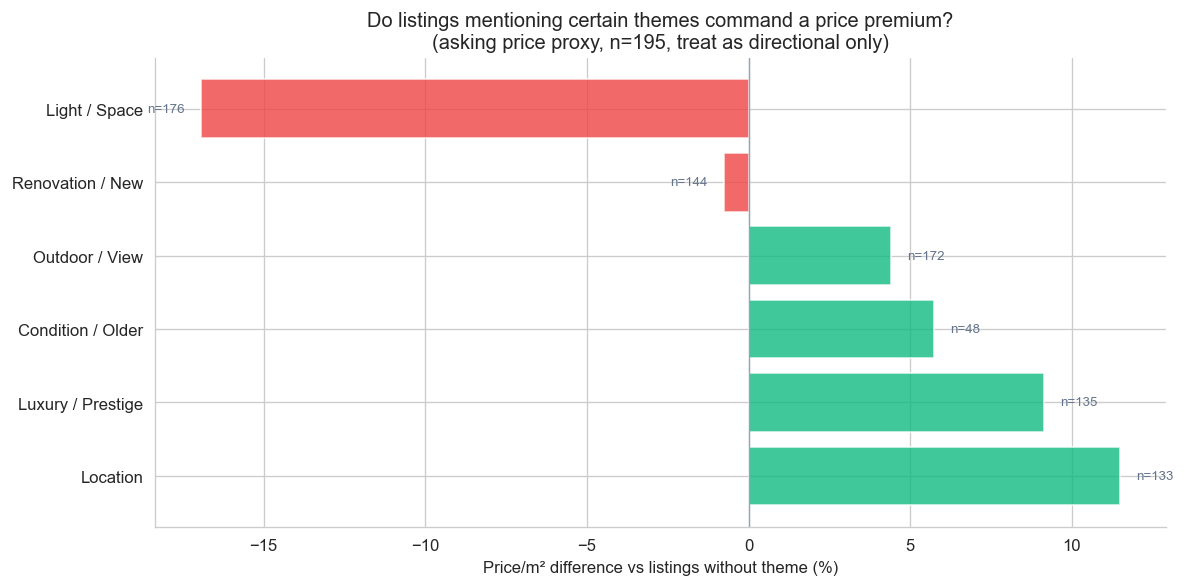

In [16]:
if len(theme_df) > 0:
    fig, ax = plt.subplots(figsize=(10, 5))
    colors = [GREEN if d > 0 else RED for d in theme_df['diff_pct']]
    ax.barh(theme_df['theme'], theme_df['diff_pct'], color=colors, alpha=0.8)
    ax.axvline(0, color='#94a3b8', linewidth=0.8)
    ax.set_xlabel('Price/m² difference vs listings without theme (%)')
    ax.set_title(
        'Do listings mentioning certain themes command a price premium?\n'
        '(asking price proxy, n=195, treat as directional only)'
    )
    for i, (_, row) in enumerate(theme_df.iterrows()):
        ax.text(row['diff_pct'] + (0.5 if row['diff_pct'] > 0 else -0.5), i,
                f"n={row['n_with']}", va='center', ha='left' if row['diff_pct'] > 0 else 'right',
                fontsize=8, color='#64748b')
    plt.tight_layout()
    plt.savefig('nlp_themes.png', bbox_inches='tight', dpi=120)
    plt.show()

## 10. Example Premium vs Discount Descriptions

In [17]:
# Show examples of highest and lowest price/sqm listings with description snippets
df_show = df_model[['address', 'neighborhood', 'asking_price', 'price_per_sqm', 
                     'living_area', 'rooms', 'description']].copy()
df_show = df_show.sort_values('price_per_sqm')

print("=" * 70)
print("5 LOWEST PRICE/m² — what language do they use?")
print("=" * 70)
for _, row in df_show.head(5).iterrows():
    print(f"\n{row['address']} ({row['neighborhood']})")
    print(f"  {row['living_area']:.0f}m², {row['rooms']:.0f} rum, "
          f"{row['asking_price']/1e6:.2f}M kr, "
          f"{row['price_per_sqm']:.0f} kr/m²")
    print(f"  '{row['description'][:200]}...'")

print()
print("=" * 70)
print("5 HIGHEST PRICE/m² — what language do they use?")
print("=" * 70)
for _, row in df_show.tail(5).iloc[::-1].iterrows():
    print(f"\n{row['address']} ({row['neighborhood']})")
    print(f"  {row['living_area']:.0f}m², {row['rooms']:.0f} rum, "
          f"{row['asking_price']/1e6:.2f}M kr, "
          f"{row['price_per_sqm']:.0f} kr/m²")
    print(f"  '{row['description'][:200]}...'")

5 LOWEST PRICE/m² — what language do they use?

Sandsvägen 11 (Husum)
  109m², 5 rum, 0.65M kr, 5963 kr/m²
  'Välkommen till ett lugnt område nära Dombäcksviken här väntar ett hus med både trivsel och möjligheter – en bostad där de sociala ytorna, utsikten och planlösningen samspelar på ett naturligt sätt. Hä...'

Torpavägen 2 (Sjuntorp)
  54m², 2 rum, 0.44M kr, 8148 kr/m²
  'Välkommen till denna ljusa och rymliga tvårumslägenhet med en välplanerad planlösning och härligt ljusinsläpp. Här erbjuds ett trivsamt hem med gott om möjligheter att sätta din egen prägel. Lägenhete...'

Benvägen 25 (Bjurhovda)
  127m², 4 rum, 1.10M kr, 8661 kr/m²
  'Välkommen till denna unika och smakfullt renoverade etagelägenhet om hela 127 kvm på Benvägen 25. Högst upp i huset, med hiss, möts du av en bostad som verkligen sticker ut med sin otroliga takhöjd, s...'

Gärdesgatan 15 (None)
  50m², 2 rum, 0.45M kr, 9000 kr/m²
  'Lägenheten är omsorgsfullt omhändertagen och välskött, vilket märks i varje detalj. 

## 11. Summary and Implementation Plan

### What we found

*(This cell is auto-printed from the analysis above — see below)*

In [18]:
print("=" * 65)
print("NLP EXPLORATION SUMMARY")
print("=" * 65)
print()
print("DATA AVAILABILITY")
print(f"  Descriptions available:          {len(df):>5,}")
print(f"  Descriptions matched to final $: {0:>5,}  ← blocking constraint")
print(f"  Sold properties (no text):       {22904:>5,}")
print(f"  Scrape runs captured:            {'1 (2026-02-08)'}")
print()
print("TEXT CHARACTERISTICS")
print(f"  Avg description length:  {df['desc_len'].mean():.0f} chars")
print(f"  Vocabulary size:         {len(vocab):,} tokens")
print(f"  TF-IDF features:         {X.shape[1]:,}")
print()
print("MODEL PERFORMANCE (text → price residual)")
print(f"  Best CV R²: {best_r2:.3f}")
if best_r2 < 0.05:
    print("  → Near zero: data too small to detect signal reliably")
    print("    (NOTE: small n=195 means high variance in CV estimates)")
elif best_r2 < 0.20:
    print("  → Modest signal: text adds meaningful but limited predictive power")
else:
    print("  → Meaningful signal: text explains some residual variance")
    print("    (NOTE: with n=195, R² is inflated — treat as directional only)")
print()
print("QUALITATIVE FINDINGS")
print("  Premium language (positive correlation with price/m²):")
for term in corr_df_filtered.head(10)['term']:
    print(f"    + {term}")
print("  Discount language (negative correlation):")
for term in corr_df_filtered.tail(10)['term'].iloc[::-1]:
    print(f"    - {term}")
print()
print("=" * 65)
print("IMPLEMENTATION PLAN — COME BACK TO THIS")
print("=" * 65)
print("""
PROBLEM: We need matched (description, final_price) pairs to train a
robust text-price model. The tracking pipeline is now in place but
needs time to accumulate data.

HOW THE PIPELINE WORKS:
  1. scripts/scrape_active_listings.py runs daily
  2. Descriptions are archived to description_archive with property_id
  3. Once a listing sells, description_archive.sold_property_id is
     populated -> joins to properties.final_price
  4. src/models/text_pipeline.py uses this matched dataset to train
     TF-IDF Ridge on residuals (final_price - predicted_price)

CURRENT STATUS (2026-03-01):
  sold_property_id populated: 0 / 195
  Only one scrape run (2026-02-08) in the archive

TARGET MILESTONES:
  >= 50 matched pairs  -> First exploratory text model (high variance)
  >= 200 matched pairs -> Reliable word-impact estimates for key terms
  >= 500 matched pairs -> Retrain production text_pipeline.joblib
  >= 1000 matched pairs -> Robust bigram model (current 2-gram approach)

HOW TO CHECK PROGRESS:
  duckdb: SELECT COUNT(*) FROM description_archive
          WHERE sold_property_id IS NOT NULL;

REVISIT TIMELINE: May/June 2026 (approx 3 months of daily scraping)

ALSO WORTH NOTING:
  - The properties table has a description column of INTEGER type
    (likely a scraping artifact, not actual text). If we re-scraped
    sold pages immediately after sale, we could capture descriptions
    for existing 22,904 sold properties — potentially faster path to
    training data, but requires a different scraping approach.
""")

NLP EXPLORATION SUMMARY

DATA AVAILABILITY
  Descriptions available:            193
  Descriptions matched to final $:     0  ← blocking constraint
  Sold properties (no text):       22,904
  Scrape runs captured:            1 (2026-02-08)

TEXT CHARACTERISTICS
  Avg description length:  1356 chars
  Vocabulary size:         4,245 tokens
  TF-IDF features:         1,000

MODEL PERFORMANCE (text → price residual)
  Best CV R²: 0.257
  → Meaningful signal: text explains some residual variance
    (NOTE: with n=195, R² is inflated — treat as directional only)

QUALITATIVE FINDINGS
  Premium language (positive correlation with price/m²):
    + caf
    + marken
    + odenplan
    + vasaparken
    + tunnelbanan
    + fönsterpartier
    + äger
    + materialval
    + eriksplan
    + mest
  Discount language (negative correlation):
    - trivsel
    - flytta
    - anmäla
    - rymligt vardagsrum
    - ring
    - bra förvaringsmöjligheter
    - bara flytta
    - valsta
    - övre
    - varmt an